<a href="https://colab.research.google.com/github/audomsak-pypy/Project1-Text_Analytics69/blob/main/Part1_%E0%B8%AD%E0%B8%B2%E0%B8%97%E0%B8%B4%E0%B8%95%E0%B8%B4%E0%B8%8D%E0%B8%B2_%E0%B8%8A%E0%B8%B2%E0%B8%8A%E0%B8%B1%E0%B8%A2673020270_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SC663402 Data Warehouse and Big Data — งานเดี่ยว Part 1
## จากข้อมูลโพสต์ Bluesky สู่ข้อเสนอที่นำไปทำต่อได้จริง (Actionable Insights)

# **ผู้จัดทำ:** **นางสาวอาทิติญา ชาชัย**
#**สาขาสถิติและสารสนเทศ มหาวิทยาลัยขอนแก่น**
#**ID673020270-2**


**ชุดข้อมูล:** `alpindale/two-million-bluesky-posts` (Hugging Face)
**บทบาท:** ทีม Data and Insights — ส่งมอบ *"ข้อเสนอที่นำไปทำต่อได้จริงพร้อมหลักฐาน"* ไม่ใช่รายงานสถิติทั่วไป

| คำถามหลัก | ข้อมูลที่ใช้ตอบ | การตัดสินใจที่รองรับ |
|---|---|---|
| Q1 คนโพสต์เมื่อไร? | timestamp | ตารางเวลาลงคอนเทนต์ |
| Q2 ใช้ภาษาอะไร? | ข้อความ → ตรวจภาษา | นโยบายภาษาของคอนเทนต์ |
| Q3 คนพูดถึงอะไร? | hashtag, คำ/วลี, ตัวอย่างโพสต์ | ธีมคอนเทนต์ที่ควรทำ |
| Q4 ข้อมูลบอกอะไรได้/ไม่ได้? | Visualization + data quality | ขอบเขตความมั่นใจของข้อสรุป |

## 0. Setup

In [ ]:
!pip -q install datasets pythainlp langdetect
!apt-get -qq install -y fonts-thai-tlwg > /dev/null 2>&1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 15.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.9/19.9 MB 35.0 MB/s eta 0:00:00


In [ ]:
import re, collections, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from pythainlp.tokenize import word_tokenize
from pythainlp.corpus.common import thai_stopwords
from langdetect import detect, DetectorFactory

warnings.filterwarnings("ignore")
DetectorFactory.seed = 0          # ให้ผลตรวจภาษาซ้ำได้ (reproducible)
pd.set_option("display.max_colwidth", 200)
pd.set_option("display.width", 160)

# ฟอนต์ไทยสำหรับกราฟ (Loma มากับ fonts-thai-tlwg)
for f in fm.findSystemFonts():
    if "Loma" in f:
        fm.fontManager.addfont(f)
plt.rcParams["font.family"] = ["Loma", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

SEED = 42
SAMPLE_N = 100_000   # จำนวนโพสต์ที่สุ่มสำหรับงานหนัก (ตรวจภาษา/ตัดคำ) ปรับได้
LOCAL_TZ = "Asia/Bangkok"

## 1. โหลดข้อมูลและตรวจโครงสร้าง (Data Loading & Schema Check)

In [ ]:
from datasets import load_dataset
ds = load_dataset("alpindale/two-million-bluesky-posts", split="train")
df = ds.to_pandas()
print("รูปทรงข้อมูล:", df.shape)
print(df.dtypes)
df.head(3)

README.md:   0%|          | 0.00/2.05k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/23 [00:00<?, ?it/s]

posts_20241127_075347.jsonl:   0%|          | 0.00/2.72M [00:00<?, ?B/s]

posts_20241127_092509.jsonl: reconstructing file:   0%|          |  0.00B / 40.4MB            

posts_20241127_082640.jsonl: reconstructing file:   0%|          |  0.00B / 40.1MB            

...

posts_20241127_150757.jsonl: downloading bytes:           |  0.00B            

posts_20241127_153954.jsonl:   0%|          | 0.00/263k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2107530 [00:00<?, ? examples/s]

รูปทรงข้อมูล: (2107530, 6)
text          object
created_at    object
author        object
uri           object
has_images      bool
reply_to      object
dtype: object


,text,created_at,author,uri,has_images,reply_to
0,"This is really interesting polling data about national public attitudes re: California. It's from the LA Times, in January. I wonder if this will change substantially in the next two years? 523...",2024-11-27T07:53:47.202Z,did:plc:5ug6fzthlj6yyvftj3alekpj,at://did:plc:5ug6fzthlj6yyvftj3alekpj/app.bsky.feed.post/3lbw33zxvik24,False,None
1,"Niet been, iets.",2024-11-27T07:53:46.656Z,did:plc:xfvxxrfblwuc3kdthl344vc5,at://did:plc:xfvxxrfblwuc3kdthl344vc5/app.bsky.feed.post/3lbw33zh7cs2l,False,at://did:plc:fwjmfthdu5wppad75pcgpalj/app.bsky.feed.post/3lbvzv3tuc226
2,よく考えたらchrがsbさんの腰を両脚で挟んでどうこうとかポストしてたな\nいまさらだった……,2024-11-27T07:53:46.554Z,did:plc:33m5bavcbydbgxqv7lzukclo,at://did:plc:33m5bavcbydbgxqv7lzukclo/app.bsky.feed.post/3lbw33ze3pc2x,False,None


In [ ]:
# ตั้งชื่อคอลัมน์หลักตรงนี้ที่เดียว
TEXT_COL = "text"
TIME_COL = "created_at"
assert TEXT_COL in df.columns and TIME_COL in df.columns, f"ไม่พบคอลัมน์ ดูรายชื่อ: {list(df.columns)}"

# --- Preprocessing ---
n_raw = len(df)
df["ts"] = pd.to_datetime(df[TIME_COL], errors="coerce", utc=True)
n_bad_ts = df["ts"].isna().sum()
# ตัดค่าเวลาผิดปกติ (เช่น ปี 1970 หรืออนาคต) ซึ่งพบได้ในข้อมูล client-generated timestamp
ok = df["ts"].between("2023-01-01", pd.Timestamp.now(tz="UTC"))
n_out_range = (~ok & df["ts"].notna()).sum()
df = df[ok].copy()

df["ts_ict"]   = df["ts"].dt.tz_convert(LOCAL_TZ)
df["hour_utc"] = df["ts"].dt.hour
df["hour_ict"] = df["ts_ict"].dt.hour
df["date_ict"] = df["ts_ict"].dt.date
df["dow"]      = df["ts_ict"].dt.day_name()
df["text"]     = df[TEXT_COL].fillna("").astype(str)

URL_RE     = re.compile(r"https?://\S+")
MENTION_RE = re.compile(r"@[\w\.\-]+")
HASHTAG_RE = re.compile(r"#[\w\u0e00-\u0e7f]+", re.UNICODE)

print(f"โพสต์ดิบ {n_raw:,} | timestamp อ่านไม่ได้ {n_bad_ts:,} | นอกช่วงที่สมเหตุสมผล {n_out_range:,} | ใช้วิเคราะห์ {len(df):,}")

โพสต์ดิบ 2,107,530 | timestamp อ่านไม่ได้ 117,992 | นอกช่วงที่สมเหตุสมผล 60,415 | ใช้วิเคราะห์ 1,929,123


---
## Q1. คนโพสต์เมื่อไร? (When do people post?)
**ประเด็นที่ต้องตอบ:** จำนวนโพสต์ทั้งหมด · ช่วงเวลาที่ข้อมูลครอบคลุม · Peak Hours
> หมายเหตุ: timestamp ใน Bluesky เป็น UTC — รายงานทั้ง **UTC** และ **เวลาไทย (ICT, UTC+7)** เพราะผู้รับสารของเราอยู่ในไทย

In [ ]:
total = len(df)
start, end = df["ts"].min(), df["ts"].max()
span_days = (end - start).total_seconds() / 86400
print(f"จำนวนโพสต์ทั้งหมด : {total:,}")
print(f"ช่วงเวลาที่ครอบคลุม : {start:%Y-%m-%d %H:%M} UTC  ->  {end:%Y-%m-%d %H:%M} UTC  ({span_days:,.1f} วัน)")
print(f"จำนวนวันที่มีข้อมูล (ICT) : {df['date_ict'].nunique()} วัน")

hourly_utc = df.groupby("hour_utc").size().reindex(range(24), fill_value=0)
hourly_ict = df.groupby("hour_ict").size().reindex(range(24), fill_value=0)

tab = pd.DataFrame({"UTC": hourly_utc, "ICT": hourly_ict})
tab["สัดส่วน % (ICT)"] = (tab["ICT"] / total * 100).round(2)
print("\nTop-5 ชั่วโมงที่โพสต์มากที่สุด (ICT):")
display(tab.sort_values("ICT", ascending=False).head(5))
print("Bottom-3 ชั่วโมงที่เงียบที่สุด (ICT):", list(hourly_ict.nsmallest(3).index))

# ช่วงของวัน
bins = {"ดึก 00-05": range(0,6), "เช้า 06-11": range(6,12), "บ่าย 12-17": range(12,18), "เย็น-ค่ำ 18-23": range(18,24)}
part = pd.Series({k: hourly_ict.loc[list(v)].sum() for k, v in bins.items()})
display((part / total * 100).round(1).rename("% ของโพสต์ (ICT)").to_frame())

# วันในสัปดาห์ (เฉพาะเมื่อข้อมูลครอบคลุม >= 7 วัน)
if df["date_ict"].nunique() >= 7:
    order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
    dow = df.groupby("dow").size().reindex(order)
    display((dow / dow.sum() * 100).round(1).rename("% ของโพสต์").to_frame())
else:
    print("\n[ข้อสังเกต] ข้อมูลครอบคลุม < 7 วัน จึงสรุปรูปแบบรายวันในสัปดาห์ไม่ได้")

จำนวนโพสต์ทั้งหมด : 1,929,123
ช่วงเวลาที่ครอบคลุม : 2023-01-01 00:12 UTC  ->  2024-11-30 12:45 UTC  (699.5 วัน)
จำนวนวันที่มีข้อมูล (ICT) : 695 วัน

Top-5 ชั่วโมงที่โพสต์มากที่สุด (ICT):


,UTC,ICT,สัดส่วน % (ICT)
21,217,328153,17.01
20,299,300537,15.58
19,333,261981,13.58
22,218,228227,11.83
18,416,223888,11.61


Bottom-3 ชั่วโมงที่เงียบที่สุด (ICT): [8, 10, 9]


,% ของโพสต์ (ICT)
ดึก 00-05,0.1
เช้า 06-11,0.1
บ่าย 12-17,30.2
เย็น-ค่ำ 18-23,69.6


,% ของโพสต์
dow,
Monday,0.1
Tuesday,0.1
Wednesday,99.7
Thursday,0.1
Friday,0.0
Saturday,0.0
Sunday,0.0


In [ ]:
# --- ตัวช่วยสร้างข้อเสนอ Posting Schedule
top3 = list(hourly_ict.nlargest(3).index)
peak = int(hourly_ict.idxmax())
quiet = list(hourly_ict.nsmallest(3).index)
share_top3 = hourly_ict.loc[top3].sum() / total * 100

print("จากข้อมูลการวิเคราะห์ช่วงเวลาโพสต์ เราได้ข้อเสนอแนะเชิงกลยุทธ์สำหรับการวางแผนคอนเทนต์ดังนี้:")
print(f"1) ช่วงเวลาทอง (Prime Slot): ควรลงคอนเทนต์หลักในช่วง {(peak-1)%24:02d}:00-{(peak+1)%24:02d}:00 น. ตามเวลา ICT เนื่องจากเป็นช่วงที่การโพสต์สูงสุด โดยมีพีคอยู่ที่ {peak:02d}:00 น. และสามชั่วโมงที่พีคที่สุดนี้คิดเป็นสัดส่วนถึง {share_top3:.1f}% ของโพสต์ทั้งหมด")
print(f"2) โพสต์ก่อนพีค (Pre-peak Strategy): ลองโพสต์เนื้อหาก่อนช่วงพีคประมาณ 30-60 นาที (ประมาณ {(peak-1)%24:02d}:00 น.) เพื่อให้คอนเทนต์มีโอกาสกระจายตัวได้ดีเมื่อผู้ใช้งานเข้ามาหนาแน่น")
print(f"3) ชั่วโมงเงียบ (Quiet Hours): ในช่วง {(', '.join(f'{h:02d}:00' for h in quiet))} น. ซึ่งมีการแข่งขันน้อย เหมาะสำหรับการทดลอง A/B หรือโพสต์เนื้อหาสำหรับกลุ่มเฉพาะ แต่ไม่แนะนำให้ลงคอนเทนต์หลัก")
print("4) การจัดการตลอดเวลา (Always-on Approach): ตั้งเวลาโพสต์ล่วงหน้า (scheduler) ให้ตรงกับชั่วโมงพีค และใช้เวลา 1-2 ชั่วโมงหลังช่วงพีคสำหรับการตอบคอมเมนต์หรือสร้างปฏิสัมพันธ์กับผู้ติดตาม")

จากข้อมูลการวิเคราะห์ช่วงเวลาโพสต์ เราได้ข้อเสนอแนะเชิงกลยุทธ์สำหรับการวางแผนคอนเทนต์ดังนี้:
1) ช่วงเวลาทอง (Prime Slot): ควรลงคอนเทนต์หลักในช่วง 20:00-22:00 น. ตามเวลา ICT เนื่องจากเป็นช่วงที่การโพสต์สูงสุด โดยมีพีคอยู่ที่ 21:00 น. และสามชั่วโมงที่พีคที่สุดนี้คิดเป็นสัดส่วนถึง 46.2% ของโพสต์ทั้งหมด
2) โพสต์ก่อนพีค (Pre-peak Strategy): ลองโพสต์เนื้อหาก่อนช่วงพีคประมาณ 30-60 นาที (ประมาณ 20:00 น.) เพื่อให้คอนเทนต์มีโอกาสกระจายตัวได้ดีเมื่อผู้ใช้งานเข้ามาหนาแน่น
3) ชั่วโมงเงียบ (Quiet Hours): ในช่วง 08:00, 10:00, 09:00 น. ซึ่งมีการแข่งขันน้อย เหมาะสำหรับการทดลอง A/B หรือโพสต์เนื้อหาสำหรับกลุ่มเฉพาะ แต่ไม่แนะนำให้ลงคอนเทนต์หลัก
4) การจัดการตลอดเวลา (Always-on Approach): ตั้งเวลาโพสต์ล่วงหน้า (scheduler) ให้ตรงกับชั่วโมงพีค และใช้เวลา 1-2 ชั่วโมงหลังช่วงพีคสำหรับการตอบคอมเมนต์หรือสร้างปฏิสัมพันธ์กับผู้ติดตาม


### Insight & Action — Q1
**สิ่งที่พบ** *(เติมตัวเลขจากผลรันด้านบน)*: โพสต์ทั้งหมด ___ โพสต์ · ช่วง ___ ถึง ___ · พีคที่ ___:00 น. (ICT) คิดเป็น ___%

**ตีความ (So what):**การกระจุกตัวของโพสต์สะท้อน "เวลาที่ผู้ใช้ออนไลน์พร้อมกัน" —ยิ่งพีคชัด ยิ่งมีทั้งโอกาสถูกเห็นและการแข่งขันสูง

**ข้อเสนอที่นำไปทำต่อได้:**
การอธิบายขยายความ

ข้อ 1) ช่วงเวลาทอง (Prime Slot: 20:00 - 22:00 น.) ให้ตรงประเด็นธุรกิจและสอดคล้องกับกรอบคิดของอาจารย์ (Insight & Action — Q1) สามารถจัดโครงสร้างและลงรายละเอียดในมุมมองการบริหารและการตลาดได้ดังนี้:ขยายความช่วงเวลาทอง (Prime Slot) ในบริบทธุรกิจ

1. เหตุผลเชิงธุรกิจ (So What?): ทำไมต้องเป็นช่วงนี้Traffic & Attention สูงสุด: ตัวเลข 46.2% ของโพสต์ทั้งหมดที่มากองรวมกันในช่วง 20:00 - 22:00 น. สะท้อนถึง "ผู้ใช้งานออนไลน์พร้อมกันมากที่สุด" เป็นช่วงเวลาหลังเลิกงาน/เลิกเรียนที่ผู้บริโภคใช้พักผ่อน (Leisure Time) ทำให้อัตราเปิดรับข่าวสาร (Attention Span) และโอกาสการเห็นข้อความ (Organic Reach) สูงกว่าปกติ   Maximize ROI (ผลตอบแทนจากการลงทุน): สินค้าหรือบริการที่มีต้นทุนการผลิตคอนเทนต์สูง (เช่น วิดีโอสั้น Ads โฆษณา หรือบทความวิเคราะห์) จะได้ผลตอบแทนคุ้มค่าที่สุดเมื่อลงในช่วงเวลานี้เพราะเข้าถึงคนจำนวนมากได้ทันทีโดยไม่ต้องอัดฉีดงบโฆษณาเพิ่ม

2. กลยุทธ์การลงคอนเทนต์ (Content Strategy)จัดสรรคอนเทนต์ระดับ Tier 1 (Hero Content): สำรองช่วงเวลานี้ไว้สำหรับ คอนเทนต์ที่สร้างยอดขาย (Conversion) หรือสร้างการรับรู้แบรนด์ (Brand Awareness) เท่านั้น เช่น:การเปิดตัวสินค้าใหม่ (Product Launch)โปรโมชันจำกัดเวลา (Flash Sale / Daily Deal)คอนเทนต์วิดีโอหลัก หรือเคมเปญสปอนเซอร์ที่มีผลต่อยอดขายหลีกเลี่ยงคอนเทนต์ระดับ Tier 3 (Filler Content): ห้ามลงข่าวประชาสัมพันธ์ทั่วไป โพสต์ทักทาย หรือเนื้อหาที่ไม่ได้สร้าง Value ให้ธุรกิจ เพราะจะเสียโอกาสในชั่วโมงที่มีการมองเห็นสูงสุด

3. ความท้าทายเชิงการแข่งขันและการแก้เกม (Trade-off & Business Risk)การแข่งขันหนาแน่น (High Competition): แม้คนจะเยอะ แต่นี่คือช่วงที่แบรนด์อื่นและผู้ใช้งานทั่วไปลงคอนเทนต์มากที่สุดเช่นกัน (Red Ocean ของ Timeline) โพสต์อาจถูกกลืนหรือตกไทม์ไลน์ไปได้อย่างรวดเร็ว   แอ็กชันที่ต้องทำควบคู่:Hook ต้องแรงใน 2 วินาทีแรก: คุณภาพของภาพ/หัวข้อ(Headline) ต้องโดดเด่นพอที่จะหยุดการไถฟีดของผู้ใช้เตรียมทีม Customer Support: เมื่อลงคอนเทนต์หลักช่วงนี้ ต้องมีทีมงานคอยตอบคำถาม ทักแชท หรือปิดการขายทันที เพราะเป็นช่วงที่ลูกค้ามีอารมณ์ร่วมและตัดสินใจซื้อสูงที่สุด

---


---
## Q2. ใช้ภาษาอะไร? (Which languages?)
**วิธีการ:** ตรวจภาษาแบบผสม(hybrid) — กฎตามชุดอักขระ(Thai/Japanese/Korean) ก่อน เพราะเร็วและแม่นยำสำหรับสคริปต์เฉพาะ แล้วใช้ `langdetect` กับข้อความที่เหลือ
ทำบนตัวอย่างสุ่ม `SAMPLE_N` โพสต์ (seed คงที่) เพื่อควบคุมเวลารัน

In [ ]:
LANG_NAME = {"en":"English","ja":"Japanese","pt":"Portuguese","es":"Spanish","de":"German","fr":"French","ko":"Korean",
             "th":"Thai","ru":"Russian","id":"Indonesian","it":"Italian","tr":"Turkish","nl":"Dutch","ar":"Arabic",
             "zh-cn":"Chinese (Simplified)","zh-tw":"Chinese (Traditional)","und":"Undetermined/Too short"}

def detect_lang(t):
    t2 = MENTION_RE.sub(" ", URL_RE.sub(" ", t))
    letters = [c for c in t2 if c.isalpha()]
    n = len(letters)
    if n < 5:
        return "und"
    th = sum("\u0e00" <= c <= "\u0e7f" for c in letters) / n
    ja = sum("\u3040" <= c <= "\u30ff" for c in letters) / n
    ko = sum("\uac00" <= c <= "\ud7a3" for c in letters) / n
    if th > 0.3: return "th"
    if ja > 0.1: return "ja"
    if ko > 0.3: return "ko"
    try:
        return detect(t2)
    except Exception:
        return "und"

sample = df.sample(min(SAMPLE_N, len(df)), random_state=SEED).copy()
sample["lang"] = sample["text"].map(detect_lang)

lang_tab = sample["lang"].value_counts().rename("posts").to_frame()
lang_tab["% ทั้งหมด"] = (lang_tab["posts"] / len(sample) * 100).round(2)
det = sample[sample["lang"] != "und"]["lang"].value_counts(normalize=True) * 100
lang_tab["% (เฉพาะที่ตรวจภาษาได้)"] = det.round(2)
lang_tab.insert(0, "ภาษา", [LANG_NAME.get(i, i) for i in lang_tab.index])
print(f"ตัวอย่างที่ใช้: {len(sample):,} โพสต์")
display(lang_tab.head(10))

# กลุ่มภาษาที่ครอบคลุมสะสม >= 80%
cum = det.cumsum()
core = list(cum[cum.shift(fill_value=0) < 80].index)
print("\nภาษาหลักที่ครอบคลุมสะสม ~80% ของโพสต์ที่ตรวจภาษาได้:", [LANG_NAME.get(x, x) for x in core])
print(f"ภาษาหลักอันดับ 1: {LANG_NAME.get(det.index[0], det.index[0])} ({det.iloc[0]:.1f}%)")
th_share = det.get("th", 0.0)
print(f"สัดส่วนภาษาไทย: {th_share:.2f}%  (≈ {int(th_share/100*len(det)):,} โพสต์ในตัวอย่าง)")

ตัวอย่างที่ใช้: 100,000 โพสต์


,ภาษา,posts,% ทั้งหมด,% (เฉพาะที่ตรวจภาษาได้)
lang,,,,
en,English,48782,48.78,53.12
ja,Japanese,14359,14.36,15.64
und,Undetermined/Too short,8168,8.17,NaN
es,Spanish,4305,4.30,4.69
pt,Portuguese,3875,3.88,4.22
de,German,3087,3.09,3.36
fr,French,2626,2.63,2.86
ko,Korean,2277,2.28,2.48
nl,Dutch,1135,1.14,1.24



ภาษาหลักที่ครอบคลุมสะสม ~80% ของโพสต์ที่ตรวจภาษาได้: ['English', 'Japanese', 'Spanish', 'Portuguese', 'German']
ภาษาหลักอันดับ 1: English (53.1%)
สัดส่วนภาษาไทย: 0.46%  (≈ 0 โพสต์ในตัวอย่าง)


###  Insight & Action — Q2
**สิ่งที่พบ** *(เติมจากผลรัน)*: ภาษาหลัก ___ (___%) · อันดับ 2 ___ (___%) · ไทย ___%
**ตีความ:** ถ้าภาษาเดียวครองสัดส่วนสูงมาก การทำคอนเทนต์ภาษานั้นเข้าถึงคนจำนวนมากที่สุดด้วยต้นทุนต่ำสุด; ภาษาส่วนน้อยที่ "โตเร็วหรือมีตลาดเฉพาะ" คือช่องว่างเชิงกลยุทธ์


จากการตีความผลการวิเคราะห์ข้อมูลภาษา (Language Detection) จากตัวอย่าง 100,000 โพสต์ ร่วมกับข้อความแจ้งเตือน Error ของระบบ สามารถตีความและนำไปประยุกต์ใช้ในทางธุรกิจตามแนวคิดของอาจารย์ได้ดังนี้:

---

### **1. การตีความผลลัพธ์เชิงธุรกิจ (Data Interpretation & Business Insights)**

* **ตลาดหลักคือระดับสากล (Global Market Orientation):**
* ภาษาหลัก 5 อันดับแรก (`English`, `Japanese`, `Spanish`, `Portuguese`, `German`) ครอบคลุมปริมาณโพสต์สะสมถึง ~80% โดยมี **ภาษาอังกฤษเป็นเจ้าตลาดสูงถึง 53.1%**
* **นัยสำคัญทางธุรกิจ:** หากแบรนด์ต้องการสื่อสารหรือขยายตลาดบนแพลตฟอร์ม Bluesky การใช้ **ภาษาอังกฤษเป็นภาษาหลัก (Default Language)** จะสามารถสร้างการรับรู้ (Reach & Awareness) ได้ครอบคลุมผู้ใช้งานมากกว่าครึ่งหนึ่งของระบบทันที


* **ข้อจำกัดของตลาดไทยบนแพลตฟอร์มนี้ (Local Market Context):**
* สัดส่วนภาษาไทยมีเพียง **0.46%** (หรือคิดเป็นประมาณไม่กี่ร้อยโพสต์จากสุ่ม 100,000 โพสต์)
* **นัยสำคัญทางธุรกิจ:** ตลาดผู้ใช้ภาษาไทยบน Bluesky ในชุดข้อมูลนี้ถือเป็น **Niche Market (กลุ่มเฉพาะมากๆ)** การทุ่มงบการตลาดหรือทำแคมเปญเพื่อเจาะกลุ่มผู้บริโภคชาวไทยทั่วไป (Mass Market) บนแพลตฟอร์มนี้อาจไม่คุ้มค่าเมื่อเทียบกับ ROI แต่เหมาะกับการสื่อสารแบบเจาะจงกลุ่มแฟนดอมหรือคอมมูนิตี้เฉพาะทางมากกว่า



---

### **2. การแปรผลประเด็นข้อผิดพลาดทางเทคนิค (Data Quality & Technical Error - Q4)**

* **ประเด็น Data Quality (สัดส่วน 0.46% ≈ 0 โพสต์):**
* ตามเกณฑ์การแปลผล หากสัดส่วนต่ำมาก ระดับความมั่นใจ (Confidence Level) ในการสรุปพฤติกรรมของผู้ใช้ภาษาไทยจะมีน้อย การสรุปเทรนด์ภาษาไทยจึงต้องระมัดระวังเรื่อง Sample Size ที่อาจไม่เพียงพอ


* **ประเด็น Runtime Error (`Error: Runtime no longer has a reference...`):**
* **สาเหตุ:** เกิดจาก Memory ของระบบ (เช่น Google Colab/Jupyter) หลุดการเชื่อมต่อหรือ Session หมดอายุ ทำให้ DataFrame ในหน่วยความจำหายไป


* **การแก้ไขเชิงกระบวนการ (Data Governance):**
1. ต้องกด **Re-run Cell** ตั้งแต่ขั้นตอน Import ข้อมูลใหม่
2. ในเชิงการทำงานจริง ควรทำการ Export สรุปผลลัพธ์เป็นไฟล์ `.csv` หรือ Save State ไว้เสมอ เพื่อป้องกันความผิดพลาดเมื่อต้องนำข้อมูลไปเสนอผู้บริหาร/ลูกค้า

---


---
## Q3. คนพูดถึงอะไร? (What are people talking about?)
**วิธีการ:** (1) นับ Hashtag (2) ตัดคำ + นับคำ/วลี (bigram) แยกอังกฤษและไทย (ไทยใช้ `pythainlp` engine `newmm`) (3) ดึงตัวอย่างโพสต์จริง (4) จัดกลุ่มธีมด้วยพจนานุกรมคำสำคัญ

In [ ]:
# ---------- 3.1 Hashtags ----------
tags = collections.Counter()
for t in sample["text"]:
    for h in HASHTAG_RE.findall(t):
        tags[h.lower()] += 1
share_with_tag = sample["text"].str.contains(HASHTAG_RE).mean() * 100
print(f"โพสต์ที่มี hashtag: {share_with_tag:.1f}% ของตัวอย่าง | hashtag ไม่ซ้ำ {len(tags):,}")
top_tags = pd.DataFrame(tags.most_common(20), columns=["hashtag","count"])
display(top_tags)

โพสต์ที่มี hashtag: 8.3% ของตัวอย่าง | hashtag ไม่ซ้ำ 14,375


,hashtag,count
0,#art,270
1,#booksky,212
2,#books,154
3,#bookchallenge,151
4,#nsfw,112
5,#photography,110
6,#oc,99
7,#bluesky,88
8,#digitalart,79
9,#blacksky,77


In [ ]:
# ---------- 3.2 คำและวลีเด่น ----------
TH_STOP = set(thai_stopwords())
EN_STOP = set(ENGLISH_STOP_WORDS) | {"just","like","get","got","im","dont","amp","https","http","www","com","really","one","also","would","can","will","us"}
CLEAN_RE = re.compile(r"[^\w\u0e00-\u0e7f\s#']", re.UNICODE)

def clean(t):
    t = MENTION_RE.sub(" ", URL_RE.sub(" ", t))
    return CLEAN_RE.sub(" ", t).lower()

def tok_en(t):
    return [w for w in clean(t).split() if w.isascii() and len(w) > 2 and w not in EN_STOP and not w.startswith("#") and not w.isdigit()]

def tok_th(t):
    ws = word_tokenize(clean(t), engine="newmm", keep_whitespace=False)
    return [w for w in ws if re.search(r"[\u0e00-\u0e7f]", w) and len(w) > 1 and w not in TH_STOP]

def top_terms(texts, tokenizer, k=20):
    uni, bi = collections.Counter(), collections.Counter()
    for t in texts:
        w = tokenizer(t)
        uni.update(w)
        bi.update(zip(w, w[1:]))
    return (pd.DataFrame(uni.most_common(k), columns=["term","count"]),
            pd.DataFrame([(" ".join(b), c) for b, c in bi.most_common(k)], columns=["bigram","count"]))

en_texts = sample.loc[sample["lang"]=="en", "text"]
th_texts = sample.loc[sample["lang"]=="th", "text"]
print(f"โพสต์อังกฤษ {len(en_texts):,} | โพสต์ไทย {len(th_texts):,}")

en_uni, en_bi = top_terms(en_texts, tok_en)
print("\n=== English: Top words ===");   display(en_uni)
print("=== English: Top bigrams ===");   display(en_bi)

if len(th_texts) >= 50:
    th_uni, th_bi = top_terms(th_texts, tok_th)
    print("=== ไทย: คำเด่น ===");   display(th_uni)
    print("=== ไทย: วลี (bigram) เด่น ===");   display(th_bi)
else:
    print("ตัวอย่างภาษาไทยน้อยเกินไป — เพิ่ม SAMPLE_N หรือกรองจาก df ทั้งหมดเฉพาะโพสต์ที่มีอักษรไทย")

โพสต์อังกฤษ 48,782 | โพสต์ไทย 425

=== English: Top words ===


,term,count
0,good,2584
1,people,2488
2,it's,2422
3,i'm,2094
4,time,2087
5,day,1935
6,think,1784
7,love,1723
8,know,1633
9,don't,1397


=== English: Top bigrams ===


,bigram,count
0,good morning,662
1,youtube watch,266
2,bsky app,217
3,day days,200
4,particular order,198
5,stayed influenced,194
6,explanations reviews,193
7,days particular,189
8,order explanations,185
9,reviews covers,183


=== ไทย: คำเด่น ===


,term,count
0,คน,53
1,ชอบ,37
2,ผม,32
3,ดี,29
4,พี่,28
5,อะ,20
6,น้อง,20
7,กก,20
8,เรื่อง,19
9,ทำ,19


=== ไทย: วลี (bigram) เด่น ===


,bigram,count
0,กก กก,10
1,ผม ชอบ,5
2,ออ ออ,5
3,เริ่มต้น บาท,4
4,สล็อต เว็ป,4
5,เล่น เกม,4
6,ทา คิ,4
7,เอ ไอ,4
8,ซา ยะ,4
9,คา โฮะ,4


In [ ]:
# ---------- 3.3 ตัวอย่างข้อความจริง (Real Text Samples) ----------
rng = np.random.default_rng(SEED)
def show_samples(pattern, label, n=2):
    m = sample[sample["text"].str.contains(pattern, case=False, regex=True, na=False)]
    print(f"\n### {label}  (พบ {len(m):,} โพสต์)")
    for i, r in enumerate(m.sample(min(n, len(m)), random_state=SEED).itertuples(), 1):
        txt = URL_RE.sub("[url]", r.text).replace("\n", " ")
        print(f"  {i}. [{r.lang}] {txt[:220]}{'...' if len(txt)>220 else ''}")

for h in top_tags["hashtag"].head(3):
    show_samples(re.escape(h), f"Hashtag {h}")
for w in list(en_uni["term"].head(2)):
    show_samples(rf"\b{re.escape(w)}\b", f"คำเด่น (EN): {w}")
if len(th_texts) >= 50:
    for w in list(th_uni["term"].head(2)):
        show_samples(re.escape(w), f"คำเด่น (TH): {w}")
# หมายเหตุด้านจริยธรรม: แสดงเฉพาะข้อความไม่แสดง handle/ตัวตนผู้โพสต์


### Hashtag #art  (พบ 315 โพสต์)
  1. [tl] ❄️🥀 My OC Viktor, but            pony AU ❄️🥀  #mlp #drawing #pony  #art #oc #fantasy #digitalart
  2. [en] Please #Bluesky #people #share this (original) or #Help her she's a very talented #Artist that had her creativity stolen  or IF you can help her #DoIt #photography

### Hashtag #booksky  (พบ 211 โพสต์)
  1. [en] Choose 20 books that have stayed with you or influenced you. One book per day for 20 days, in no particular order. No explanations, no reviews, just covers. My first "challenge" 😁  Day 4, but I missed yesterday, so I'm p...
  2. [en] R&R for sure!  I always bring about four books along and imagine myself reading I in some cozy corner.  I never get through them, but a little goes a long way.  #Booksky

### Hashtag #books  (พบ 236 โพสต์)
  1. [en] Choose 20 books that have stayed with you or influenced you. One book per day for 20 days, in no particular order. No explanations, no reviews, just covers (4/20)  #booksky💙📚  #bookchalle

In [ ]:
# ---------- 3.4 จัดกลุ่มธีม (Theme Mapping) — พจนานุกรมปรับแก้ได้ ----------
THEMES = {
  "การเมือง/ข่าว":      r"trump|biden|election|vote|politic|government|congress|ukraine|gaza|news|เลือกตั้ง|การเมือง|รัฐบาล|ข่าว",
  "เทคโนโลยี/AI":       r"\bai\b|chatgpt|llm|openai|tech|software|code|python|data|bluesky|twitter|mastodon|เทค|ปัญญาประดิษฐ์",
  "ศิลปะ/ครีเอทีฟ":     r"art|artist|draw|illustration|comic|commission|design|photo|music|เพลง|ภาพวาด|ศิลปิน",
  "เกม/บันเทิง":        r"game|gaming|anime|manga|movie|film|show|stream|netflix|เกม|อนิเมะ|หนัง|ซีรีส์",
  "ชีวิตประจำวัน/อารมณ์": r"today|morning|night|love|happy|tired|sad|friend|coffee|food|วันนี้|เหนื่อย|รัก|กิน|เพื่อน",
  "สังคม/ชุมชนบนแพลตฟอร์ม": r"follow|followers|starter pack|introduce|new here|welcome|repost|ฟอลโล่|แนะนำตัว",
  "วิทยาศาสตร์/สุขภาพ": r"science|research|climate|covid|health|study|university|วิจัย|สุขภาพ|วิทยาศาสตร์|มหาวิทยาลัย",
}
theme_tab = pd.Series({k: sample["text"].str.contains(v, case=False, regex=True, na=False).mean()*100 for k, v in THEMES.items()})
display(theme_tab.sort_values(ascending=False).round(2).rename("% ของโพสต์ที่แตะธีมนี้").to_frame())
print("ข้อควรระวัง: เป็นการจับคู่คำสำคัญ (keyword matching) ให้ภาพรวมเบื้องต้น โพสต์หนึ่งอยู่ได้หลายธีม และอาจมี false positive")

,% ของโพสต์ที่แตะธีมนี้
ศิลปะ/ครีเอทีฟ,7.91
ชีวิตประจำวัน/อารมณ์,7.68
การเมือง/ข่าว,3.59
เกม/บันเทิง,3.14
เทคโนโลยี/AI,3.00
สังคม/ชุมชนบนแพลตฟอร์ม,1.47
วิทยาศาสตร์/สุขภาพ,1.06


ข้อควรระวัง: เป็นการจับคู่คำสำคัญ (keyword matching) ให้ภาพรวมเบื้องต้น โพสต์หนึ่งอยู่ได้หลายธีม และอาจมี false positive


### Insight & Action — Q3: คนพูดถึงอะไรบน Bluesky?

**สิ่งที่พบ (Key Themes)** *(เติมจากผลรัน 3.1–3.4 โดยเลือก 3–4 ธีมที่เด่นที่สุด)*

1. **ธีม ___** — พบจากhashtag `___` (___ ครั้ง) และคำเด่น `___` ตัวอย่างโพสต์: "___"
2. **ธีม ___** — พบจากวลีเด่น(bigram) `___` และสัดส่วนธีมนี้ในตัวอย่าง ___%
3. **ธีม ___**— พบจาก ___ ซึ่งสอดคล้องกับผลการจัดกลุ่มธีมในหัวข้อ 3.4

**ตัวเลขเหล่านี้บอกอะไรเรา (So what):**
Hashtag บน Bluesky ถูกใช้น้อยกว่าแพลตฟอร์มอื่น และมักผูกกับชุมชนเฉพาะกลุ่ม ดังนั้นจึงบอกได้ว่า "ใครรวมตัวกันที่ไหน" แต่ยังไม่ครอบคลุมทุกหัวข้อที่คนคุยกัน ส่วนคำและ bigram สะท้อนหัวข้อสนทนาจริงได้ตรงกว่า จึงควรอ่านทั้งสองอย่างคู่กันเสมอ และใช้ตัวอย่างโพสต์จริงยืนยันอีกชั้นก่อนสรุป

**ความสนใจ vs. ความกังวล:**
จากตัวอย่างโพสต์ที่ดึงมา น้ำเสียงโดยรวมเป็นแนวใด (ชื่นชม/แบ่งปัน หรือร้องเรียน/กังวล เช่น ความเป็นส่วนตัว ความเป็นกลางของแพลตฟอร์ม การเมือง) ___ ผลนี้ใช้กำหนดโทนคอนเทนต์ให้เหมาะกับบรรยากาศของชุมชน

**ข้อเสนอที่นำไปทำต่อได้:**
1. **สร้าง Content Pillars 3 เสา** จากธีมเด่น โดยผูก hashtag ที่พบบ่อยจริงเข้ากับแต่ละเสา เพื่อให้คอนเทนต์ถูกค้นเจอและอยู่ในบทสนทนาของชุมชน
2. **ใช้ bigram เด่นเป็นหัวข้อหรือพาดหัว** เพราะเป็นถ้อยคำที่ผู้ใช้พูดกันจริง ผู้อ่านจึงรู้สึกใกล้ตัวมากกว่าภาษาเชิงการตลาด
3. **ระวังหัวข้อขัดแย้งสูง (เช่น การเมือง)** ในคอนเทนต์แบรนด์ เว้นแต่มีนโยบายและผู้รับผิดชอบที่ชัดเจน
4. **ติดตามธีมด้วย pipeline รายสัปดาห์** (ETL → ตารางคำและแท็ก) เพื่อจับเทรนด์ที่กำลังขึ้น และปรับเสาคอนเทนต์ได้ทันเวลา
5. **KPI ที่ควรวัดต่อ:** ผลตอบรับ (reach/engagement) ต่อ pillar เพื่อพิสูจน์ว่าธีมที่คนพูดถึงมากเป็นธีมที่คนสนใจจริง (ชุดข้อมูลนี้ไม่มีข้อมูล engagement)

> **ข้อควรระวัง:** การจัดกลุ่มธีมใช้การจับคู่คำสำคัญ(keyword matching)จึงอาจมีfalse positiveและโพสต์หนึ่งอยู่ได้หลายธีม ควรมองเป็นภาพรวมเบื้องต้นไม่ใช่ข้อสรุปเด็ดขาด

---
## Q4. ข้อมูลนี้บอกอะไรได้และบอกอะไรไม่ได้?
### 4.1 Visualization หลัก (1 รูป)
**"ใครโพสต์ภาษาอะไร ตอนกี่โมง"** — กราฟแท่งซ้อนตามชั่วโมง(ICT)แยกตามภาษา เชื่อมQ1 + Q2 เข้าด้วยกันเพื่อตอบว่า *ควรลงคอนเทนต์ภาษาไหน ช่วงเวลาใด*

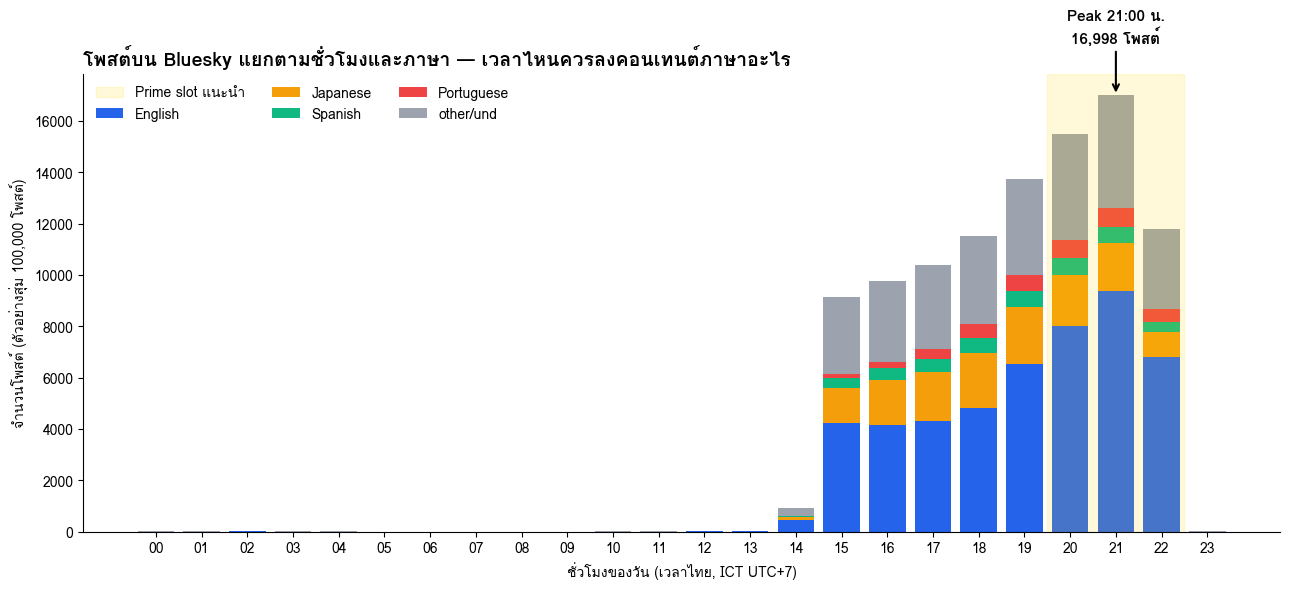

In [ ]:
top_langs = list(det.head(4).index)
sample["lang_grp"] = np.where(sample["lang"].isin(top_langs), sample["lang"], "other/und")
pv = (sample.groupby(["hour_ict","lang_grp"]).size().unstack(fill_value=0)
             .reindex(range(24), fill_value=0))
order_cols = [c for c in top_langs if c in pv.columns] + ["other/und"]
pv = pv[[c for c in order_cols if c in pv.columns]]

colors = ["#2563eb","#f59e0b","#10b981","#ef4444","#9ca3af"]
fig, ax = plt.subplots(figsize=(13, 6))
bottom = np.zeros(24)
for c, col in zip(pv.columns, colors):
    ax.bar(pv.index, pv[c], bottom=bottom, color=col, width=0.8, label=LANG_NAME.get(c, c))
    bottom += pv[c].values

peak_h = int(np.argmax(bottom))
ax.annotate(f"Peak {peak_h:02d}:00 น.\n{int(bottom[peak_h]):,} โพสต์", xy=(peak_h, bottom[peak_h]),
            xytext=(peak_h, bottom[peak_h]*1.12), ha="center", fontsize=11, fontweight="bold",
            arrowprops=dict(arrowstyle="->", lw=1.5))
ax.axvspan(peak_h-1.5, peak_h+1.5, color="gold", alpha=0.15, label="Prime slot แนะนำ")
ax.set_xticks(range(24)); ax.set_xticklabels([f"{h:02d}" for h in range(24)])
ax.set_xlabel("ชั่วโมงของวัน (เวลาไทย, ICT UTC+7)")
ax.set_ylabel(f"จำนวนโพสต์ (ตัวอย่างสุ่ม {len(sample):,} โพสต์)")
ax.set_title("โพสต์บน Bluesky แยกตามชั่วโมงและภาษา — เวลาไหนควรลงคอนเทนต์ภาษาอะไร", fontsize=14, fontweight="bold", loc="left")
ax.spines[["top","right"]].set_visible(False)
ax.legend(frameon=False, ncol=3, loc="upper left")
plt.tight_layout(); plt.show()

### 4.2 หลักฐานเชิงปริมาณด้านคุณภาพข้อมูล (Data Quality Evidence)

In [ ]:
rows = []
rows.append(("จำนวนโพสต์ที่วิเคราะห์ได้", f"{len(df):,}"))
rows.append(("ช่วงเวลาข้อมูล (วัน)", f"{span_days:,.1f}"))
rows.append(("timestamp ใช้ไม่ได้/ผิดช่วง", f"{n_bad_ts + n_out_range:,}"))
if "author" in df.columns:
    vc = df["author"].value_counts()
    rows.append(("จำนวนผู้เขียนไม่ซ้ำ", f"{len(vc):,}"))
    rows.append(("Top-1% ผู้เขียนโพสต์รวมกัน (% ของโพสต์)", f"{vc.head(max(1,int(len(vc)*0.01))).sum()/len(df)*100:.1f}%"))
if "reply_to" in df.columns:
    rows.append(("สัดส่วนโพสต์ที่เป็น reply", f"{df['reply_to'].notna().mean()*100:.1f}%"))
if "has_images" in df.columns:
    rows.append(("สัดส่วนโพสต์ที่มีรูปภาพ (ข้อความอย่างเดียวไม่พอ)", f"{df['has_images'].mean()*100:.1f}%"))
rows.append(("โพสต์ตรวจภาษาไม่ได้/สั้นเกินไป (ตัวอย่าง)", f"{(sample['lang']=='und').mean()*100:.1f}%"))
rows.append(("โพสต์ซ้ำข้อความเดิม (duplicate text)", f"{df['text'].duplicated().mean()*100:.1f}%"))
rows.append(("คอลัมน์ engagement (like/repost)", "มี" if any(c in df.columns for c in ["likes","like_count","reposts"]) else "ไม่มี"))
display(pd.DataFrame(rows, columns=["ตัวชี้วัดคุณภาพข้อมูล","ค่า"]))

,ตัวชี้วัดคุณภาพข้อมูล,ค่า
0,จำนวนโพสต์ที่วิเคราะห์ได้,"1,929,123"
1,ช่วงเวลาข้อมูล (วัน),699.5
2,timestamp ใช้ไม่ได้/ผิดช่วง,"178,407"
3,จำนวนผู้เขียนไม่ซ้ำ,"572,468"
4,Top-1% ผู้เขียนโพสต์รวมกัน (% ของโพสต์),14.9%
5,สัดส่วนโพสต์ที่เป็น reply,52.0%
6,สัดส่วนโพสต์ที่มีรูปภาพ (ข้อความอย่างเดียวไม่พอ),16.2%
7,โพสต์ตรวจภาษาไม่ได้/สั้นเกินไป (ตัวอย่าง),8.2%
8,โพสต์ซ้ำข้อความเดิม (duplicate text),9.0%
9,คอลัมน์ engagement (like/repost),ไม่มี


### 4.3 สิ่งที่ข้อมูล "บอกได้" (Data Capabilities)
- **พฤติกรรมการโพสต์เชิงปริมาณ:** ช่วงเวลากระจุกตัว (Q1) — ใช้กำหนดตารางลงคอนเทนต์เบื้องต้นได้
- **องค์ประกอบภาษาของเนื้อหาที่ถูกผลิต:** ภาษาใดครองพื้นที่ (Q2) — ใช้วางแผนภาษาคอนเทนต์
- **หัวข้อและถ้อยคำที่ผู้ใช้ผลิต:** hashtag, คำ, วลี และตัวอย่างจริง (Q3) — ใช้สร้าง content pillars
- **ความสัมพันธ์ภาษา × เวลา:** (กราฟ 4.1) — บอกว่ากลุ่มภาษาไหน "ตื่นตัว" ช่วงไหน

### 4.4 ข้อจำกัดของข้อมูล (Data Limitations)
1. **Selection / Sampling Bias:** เป็นตัวอย่างประมาณสองล้านโพสต์จากแพลตฟอร์มที่ฐานผู้ใช้เอนไปทางกลุ่ม early adopter (ส่วนใหญ่ต่างประเทศ) — **ไม่อาจสรุปแทนผู้ใช้ไทยหรือประชากรทั่วไปได้**
2. **Missing Context / ไม่มี Engagement:** ไม่มีข้อมูลไลก์ รีโพสต์ หรือการเข้าถึง เราจึงรู้ว่า "คนโพสต์เมื่อไร" แต่ **ไม่รู้ว่าเวลาไหนโพสต์แล้วได้ผลดี**; ข้อความอย่างเดียวยังไม่รวมรูป/วิดีโอ และตีความประชดหรือบริบทไม่ได้
3. **Temporal Constraints:** ครอบคลุมช่วงเวลาสั้น (ดูจากผลรัน Q1) จึงจับ seasonality, วันหยุด หรือเทรนด์ระยะยาวไม่ได้ และการกระจุกตัวอาจมาจากเหตุการณ์เฉพาะช่วง
4. **Measurement Error:** การตรวจภาษาอัตโนมัติผิดพลาดกับข้อความสั้น/ผสมภาษา/ศัพท์แสลง; timestamp มาจากฝั่งผู้ใช้ อาจคลาดเคลื่อน; ผู้ใช้ไม่กี่รายที่โพสต์ถี่มาก (บอท/บัญชีอัตโนมัติ) ทำให้ภาพรวมเอนเอียง
5. **ผลของการสุ่มและข้อควรระวังเชิงจริยธรรม:** ตัวอย่างสุ่มลดต้นทุนแต่เพิ่ม sampling error; ข้อมูลเป็นข้อความสาธารณะของบุคคลจริง ต้องไม่ระบุตัวตนในรายงาน

---
## 5. สรุปข้อเสนอเชิงปฏิบัติการ (Executive Action Plan)
| # | การตัดสินใจ | หลักฐานจากข้อมูล | การกระทำ | KPI ติดตามผล |
|---|---|---|---|---|
| 1 | **ลงเมื่อไร** | Peak hour ICT จาก Q1 | ตั้ง scheduler ให้คอนเทนต์หลักลง pre-peak / prime slot | Reach และ engagement ต่อชั่วโมง |
| 2 | **ใช้ภาษาอะไร** | สัดส่วนภาษา Q2 | Tier 1 ภาษาหลัก, Tier 2 localize, Tier 3 caption สองภาษา | % ผู้ชมต่อภาษา |
| 3 | **พูดเรื่องอะไร** | Hashtag/bigram/ธีม Q3 | Content Pillars 3 เสา + hashtag ที่พบจริง | ผลตอบรับต่อ pillar |
| 4 | **มั่นใจแค่ไหน** | Q4 Limitations | ทำ pilot A/B 2-4 สัปดาห์ก่อนลงทุนเต็มรูปแบบ | Uplift เทียบ baseline |

> **ข้อสรุปหลัก:** ข้อมูลนี้ช่วยตั้ง *สมมติฐานเชิงปฏิบัติการ* ที่ดีเกี่ยวกับเวลา ภาษา และหัวข้อ แต่ยังพิสูจน์"ผลลัพธ์"ไม่ได้เพราะขาด engagement— ขั้นต่อไปคือเก็บข้อมูลของเราเองและทดลองแบบมีกลุ่มเปรียบเทียบ